In [13]:
from functools import reduce
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [2]:
preds_path_ls = [
    ('Raw 1b',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\Raw_1b.bin'),
    ('LoRA_1b-CR',   r'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\LoRA_1b-cfg1-CR.bin')
]

for st in range(2_000, 16_000+1, 2_000):
    preds_path_ls.append(
        (f'LoRA_1b-code st-{st}',   rf'C:\Users\Vladimir\PycharmProjects\OrthogonalFineTune\HumanEval\LoRA_1b-cfg1-st{st}.bin'),
    )

In [3]:
preds_dfs = {}

for run_name, preds_path in preds_path_ls:
    with open(preds_path, 'rb') as f:
        preds_dfs[run_name] = pickle.load(file=f)

        print(f"{run_name:16}: {preds_dfs[run_name].shape=}")

Raw 1b          : preds_dfs[run_name].shape=(164, 7)
LoRA_1b-CR      : preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-2000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-4000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-6000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-8000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-10000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-12000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-14000: preds_dfs[run_name].shape=(164, 7)
LoRA_1b-code st-16000: preds_dfs[run_name].shape=(164, 7)


In [4]:
run_name = 'LoRA_1b-code st-16000'

In [5]:
preds_dfs[run_name]

,task_id,prompt,canonical_solution,test,entry_point,text_wa_answer,model_pred
0,HumanEval/0,from typing import List\n\n\ndef has_close_ele...,"for idx, elem in enumerate(numbers):\n ...","\n\nMETADATA = {\n 'author': 'jt',\n 'da...",has_close_elements,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def has_close_elements(num...
1,HumanEval/1,from typing import List\n\n\ndef separate_pare...,result = []\n current_string = []\n ...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",separate_paren_groups,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List d...
2,HumanEval/2,\n\ndef truncate_number(number: float) -> floa...,return number % 1.0\n,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",truncate_number,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def truncate_number(number...
3,HumanEval/3,from typing import List\n\n\ndef below_zero(op...,balance = 0\n\n for op in operations:\n...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",below_zero,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'from typing import List d...
4,HumanEval/4,from typing import List\n\n\ndef mean_absolute...,mean = sum(numbers) / len(numbers)\n re...,"\n\nMETADATA = {\n 'author': 'jt',\n 'da...",mean_absolute_deviation,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def mean_absolute_deviatio...
...,...,...,...,...,...,...,...
159,HumanEval/159,"\ndef eat(number, need, remaining):\n """"""\n...",if(need <= remaining):\n return [ n...,def check(candidate):\n\n # Check some simp...,eat,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'def eat(number, need, rema..."
160,HumanEval/160,"\ndef do_algebra(operator, operand):\n """"""\...",expression = str(operand[0])\n for oprt...,def check(candidate):\n\n # Check some simp...,do_algebra,<|begin_of_text|><|start_header_id|>system<|en...,"{'generated_text': 'def do_algebra(operator, o..."
161,HumanEval/161,"\ndef solve(s):\n """"""You are given a string...",flg = 0\n idx = 0\n new_str = list(s...,def check(candidate):\n\n # Check some simp...,solve,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def solve(s): if not s...
162,HumanEval/162,"\ndef string_to_md5(text):\n """"""\n Given...",import hashlib\n return hashlib.md5(tex...,def check(candidate):\n\n # Check some simp...,string_to_md5,<|begin_of_text|><|start_header_id|>system<|en...,{'generated_text': 'def string_to_md5(text): ...


In [6]:
import itertools
import re

def parse_compleetion(generated: str, entry_point: str) -> str:
    entry_pos = generated.find(entry_point)

    code_lines = generated[entry_pos:].split('\n')
    code_lines = itertools.takewhile(
        lambda line: re.match(r"^( {4}|\t)", line) or (len(line) == 0),
        itertools.islice(code_lines, 1, None)
    )

    return '\n'.join(code_lines)

In [7]:
idx = 1

# print(preds_dfs[run_name]['model_pred'][idx]['generated_text'])
# print(len(preds_dfs[run_name]['model_pred'][idx]['generated_text'].split('\n')[7]))

print(preds_dfs[run_name]['prompt'][idx])
print(parse_compleetion(preds_dfs[run_name]['model_pred'][idx]['generated_text'], entry_point=preds_dfs[run_name]['entry_point'][idx]))

from typing import List


def separate_paren_groups(paren_string: str) -> List[str]:
    """ Input to this function is a string containing multiple groups of nested parentheses. Your goal is to
    separate those group into separate strings and return the list of those.
    Separate groups are balanced (each open brace is properly closed) and not nested within each other
    Ignore any spaces in the input string.
    >>> separate_paren_groups('( ) (( )) (( )( ))')
    ['()', '(())', '(()())']
    """

    paren_string = paren_string.replace(" ", "")
    paren_string = paren_string.replace("(", " ")
    paren_string = paren_string.replace(")", " ")
    paren_string = paren_string.split()
    result = []
    stack = []
    for paren in paren_string:
        if paren == '(':
            stack.append(paren)
        elif paren == ')':
            if stack:
                stack.pop()
                result.append(paren)
    return result



In [8]:
from typing import Dict, Any
import tempfile
import subprocess
import concurrent.futures
import sys
import os


def evaluate_single_solution(problem: Dict[str, Any], completion: str) -> bool:
    """
    Evaluate a single solution for a HumanEval problem.
    Returns True if all test cases pass, False otherwise.
    """
    # Combine prompt, completion and test code
    full_code = (
        problem["prompt"] + 
        completion + 
        "\n" +
        problem["test"] +
        "\n\n" +
        f"check({problem['entry_point']})"
    )

    # print(full_code)

    # Create temporary file to execute the code
    with tempfile.TemporaryDirectory() as temp_dir:
        script_path = os.path.join(temp_dir, "script.py")
        # Write the script to a temporary file
        with open(script_path, "w", encoding='utf-8') as f:
            f.write(full_code)
        
        result = {"stdout": None, "stderr": None, "success": False, "returncode": None, "error_type": None}
        try:
            # Run the code with a timeout
            process = subprocess.run(
                [sys.executable, script_path],
                # capture_output=True,
                text=True,
                timeout=5,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                cwd=temp_dir,
            )
            result["stdout"] = process.stdout
            result["stderr"] = process.stderr
            result["returncode"] = process.returncode
            result["success"] = process.returncode == 0
        except subprocess.TimeoutExpired:
            result["stderr"] = "Script execution timed out."
        except Exception as e:
            result["stderr"] = f"Error during script execution: {e}"
    
    if not result["success"]:
        error_type = re.findall('AssertionError|SyntaxError|NameError', result["stderr"])
        result["error_type"] = 'Smth else' if len(error_type) == 0 else error_type[0]

    return result['success'], result

In [9]:
def score_run(preds_df: pd.DataFrame) -> tuple[float, list[str], list]:
    score = 0
    error_types = []
    eval_results = []

    assert all(
        'def check(candidate):' in preds_df['test'][idx]
        for idx in range(preds_df.shape[0])
    )

    for idx in range(preds_df.shape[0]):
        success, result = evaluate_single_solution(
            problem=dict(preds_df.iloc[idx]),
            completion=parse_compleetion(preds_df['model_pred'][idx]['generated_text'], entry_point=preds_df['entry_point'][idx])
        )

        score += success
        error_types.append(result['error_type'])
        eval_results.append(result)
    
    score = score / preds_dfs[run_name].shape[0]

    return score, error_types, eval_results

In [14]:
scores = []

for run_name in preds_dfs.keys():
    score, error_types, eval_results = score_run(preds_dfs[run_name])
    scores.append(score)

    print(f"{run_name=:24}\t\t{score:.4f}")

run_name=Raw 1b                  		0.2805
run_name=LoRA_1b-CR              		0.1037
run_name=LoRA_1b-code st-2000    		0.3171
run_name=LoRA_1b-code st-4000    		0.3232
run_name=LoRA_1b-code st-6000    		0.3232
run_name=LoRA_1b-code st-8000    		0.3537
run_name=LoRA_1b-code st-10000   		0.3780
run_name=LoRA_1b-code st-12000   		0.4024
run_name=LoRA_1b-code st-14000   		0.4024
run_name=LoRA_1b-code st-16000   		0.4268


Text(0, 0.5, 'HumanEval top-1 accuracy')

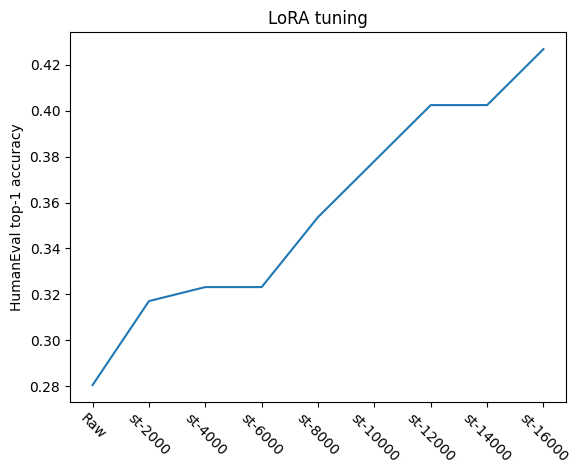

In [25]:
sns.lineplot(
    x=range(0, 16000+1, 2000),
    y=scores[0:1] + scores[2:],
)

plt.xticks(
    range(0, 16000+1,2000),
    labels=['Raw'] + [f'st-{st}' for st in range(2000, 16000+1,2000)],
    rotation=-45
)

plt.title('LoRA tuning')
plt.ylabel('HumanEval top-1 accuracy')

In [11]:
from collections import Counter

Counter(error_types)

Counter({'AssertionError': 75,
         None: 70,
         'Smth else': 10,
         'NameError': 8,
         'SyntaxError': 1})

In [12]:
for i, (err_type, result) in enumerate(zip(error_types, eval_results)):
    if err_type != 'Smth else':
        continue

    detailed_err_type = re.findall('\n\w+Error', result['stderr'])[0].strip()

    print(f"Problem {i:3}\tError={detailed_err_type}")

Problem  19	Error=ValueError
Problem  32	Error=ValueError
Problem  67	Error=ValueError
Problem  78	Error=ValueError
Problem  81	Error=KeyError
Problem 103	Error=ValueError
Problem 108	Error=ValueError
Problem 111	Error=ValueError
Problem 118	Error=IndexError
Problem 145	Error=ValueError
